In [7]:
import numpy as np
import networkx as nx
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

from networkx.algorithms.community import (
    greedy_modularity_communities,
    modularity
)

# Louvain (optional)
try:
    from networkx.algorithms.community import louvain_communities
except ImportError:
    louvain_communities = None

In [2]:
def detect_communities_undirected(Gu):
    # Prefer Louvain if available
    if louvain_communities is not None:
        try:
            comms = louvain_communities(Gu, weight="weight", seed=42)
        except Exception:
            comms = list(greedy_modularity_communities(Gu, weight="weight"))
    else:
        comms = list(greedy_modularity_communities(Gu, weight="weight"))

    Q = modularity(Gu, comms, weight="weight")

    print("Modularity:", Q)
    print("Number of communities:", len(comms))

    return comms, Q

def community_metrics(Gu, comms, label=""):
    node_to_comm = {}
    for i, c in enumerate(comms):
        for n in c:
            node_to_comm[n] = i

    sizes = np.array([len(c) for c in comms])

    intra_edges = 0
    inter_edges = 0

    for u, v in Gu.edges():
        if node_to_comm.get(u) == node_to_comm.get(v):
            intra_edges += 1
        else:
            inter_edges += 1

    # -------------------------
    # Community Size Distribution (log-log)
    # -------------------------
    if len(sizes) > 0:
        sizes_nonzero = sizes[sizes > 0]

        bins = np.logspace(np.log10(sizes_nonzero.min()), np.log10(sizes_nonzero.max()), 20)
        hist, edges = np.histogram(sizes_nonzero, bins=bins)
        centers = np.sqrt(edges[:-1] * edges[1:])

        plt.figure()
        plt.loglog(centers, hist, 'o')
        plt.xlabel("Community Size")
        plt.ylabel("Frequency")
        plt.title(f"Community Size Distribution {label}")
        plt.show()

    # -------------------------
    # Histogram (linear)
    # -------------------------
    plt.figure()
    plt.hist(sizes, bins=30)
    plt.xlabel("Community Size")
    plt.ylabel("Count")
    plt.title(f"Community Size Histogram {label}")
    plt.show()

    return {
        "num_communities": len(comms),
        "community_sizes": sizes,
        "largest_community_size": int(sizes.max()) if len(sizes) else 0,
        "intra_edges": intra_edges,
        "inter_edges": inter_edges,
        "intra_ratio": intra_edges / (intra_edges + inter_edges) if (intra_edges + inter_edges) else np.nan,
    }

def community_internal_density(Gu, comms, label=""):
    densities = []

    for c in comms:
        sub = Gu.subgraph(c)
        n = sub.number_of_nodes()
        m = sub.number_of_edges()

        if n > 1:
            density = 2 * m / (n * (n - 1))
            densities.append(density)

    plt.figure()
    plt.hist(densities, bins=30)
    plt.xlabel("Internal Density")
    plt.ylabel("Count")
    plt.title(f"Community Internal Density {label}")
    plt.show()

    return densities

def community_strength_analysis(Gu, comms, label=""):
    comm_strengths = []

    for c in comms:
        sub = Gu.subgraph(c)
        total_strength = sum(dict(sub.degree(weight="weight")).values())
        comm_strengths.append(total_strength)

    comm_strengths = np.array(comm_strengths)

    if len(comm_strengths) > 0:
        bins = np.logspace(np.log10(comm_strengths.min()+1e-6),
                           np.log10(comm_strengths.max()), 20)
        hist, edges = np.histogram(comm_strengths, bins=bins)
        centers = np.sqrt(edges[:-1] * edges[1:])

        plt.figure()
        plt.loglog(centers, hist, 'o')
        plt.xlabel("Community Strength")
        plt.ylabel("Frequency")
        plt.title(f"Community Strength Distribution {label}")
        plt.show()

    return comm_strengths

def annotate_communities(Gu, comms):
    node_to_comm = {}
    for i, c in enumerate(comms):
        for n in c:
            node_to_comm[n] = i

    nx.set_node_attributes(Gu, node_to_comm, "community")
    return node_to_comm

def community_report(Gd, Gu, label=""):
    print(f"\n===== COMMUNITY ANALYSIS: {label} =====")

    comms, Q = detect_communities_undirected(Gu)

    stats = community_metrics(Gu, comms, label=label)
    densities = community_internal_density(Gu, comms, label=label)
    strengths = community_strength_analysis(Gu, comms, label=label)

    node_to_comm = annotate_communities(Gu, comms)

    # -------------------------
    # Top ports per community
    # -------------------------
    comm_top_ports = {}
    for i, c in enumerate(comms):
        sub = Gu.subgraph(c)
        top = sorted(sub.degree(weight="weight"), key=lambda x: x[1], reverse=True)[:10]
        comm_top_ports[i] = top

    print("Top communities (by size):", sorted(stats["community_sizes"], reverse=True)[:5])

    return {
        "modularity": Q,
        "community_stats": stats,
        "internal_densities": densities,
        "community_strengths": strengths,
        "node_to_comm": node_to_comm,
        "top_ports_per_community": comm_top_ports,
    }

In [3]:
def build_ship_sequences(df, remove_consecutive_duplicates=True):
    ship_paths = {}

    for ship_id, g in df.groupby("ship_id", sort=False):
        g = g.sort_values("entry_time")
        ports = g["port_id"].tolist()

        if remove_consecutive_duplicates:
            cleaned = []
            for p in ports:
                if not cleaned or cleaned[-1] != p:
                    cleaned.append(p)
            ports = cleaned

        if len(ports) >= 2:
            ship_paths[ship_id] = ports

    return ship_paths

def build_directed_weighted_graph(ship_paths):
    edge_w = defaultdict(int)

    for ship_id, ports in ship_paths.items():
        for u, v in zip(ports[:-1], ports[1:]):
            if u != v:
                edge_w[(u, v)] += 1

    G = nx.DiGraph()
    for (u, v), w in edge_w.items():
        G.add_edge(u, v, weight=w)

    return G

def build_undirected_weighted_graph(Gd):
    Gu = nx.Graph()

    for u, v, data in Gd.edges(data=True):
        w = data.get("weight", 1)

        if Gu.has_edge(u, v):
            Gu[u][v]["weight"] += w
        else:
            Gu.add_edge(u, v, weight=w)

    return Gu


===== COMMUNITY ANALYSIS: 2015 =====
Modularity: 0.6986745597059939
Number of communities: 28


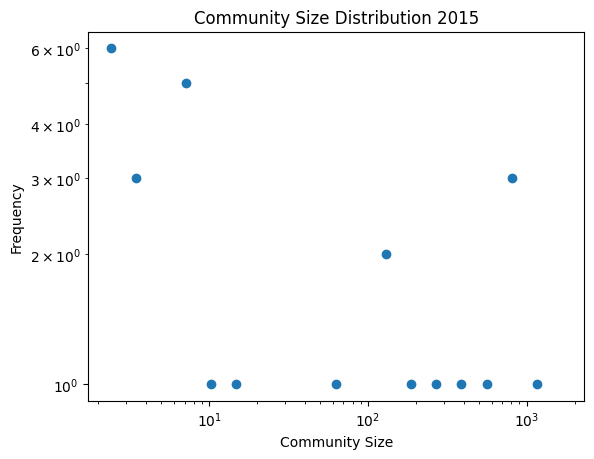

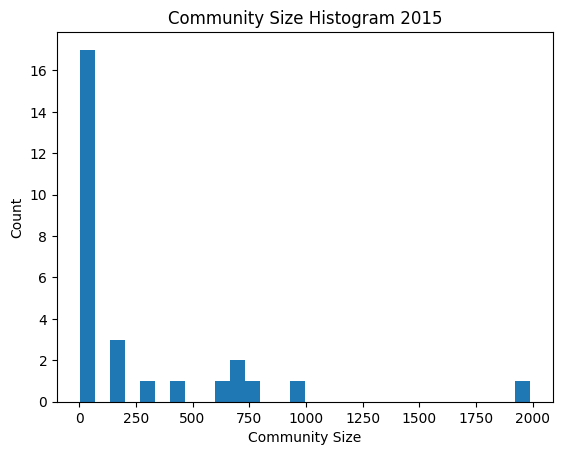

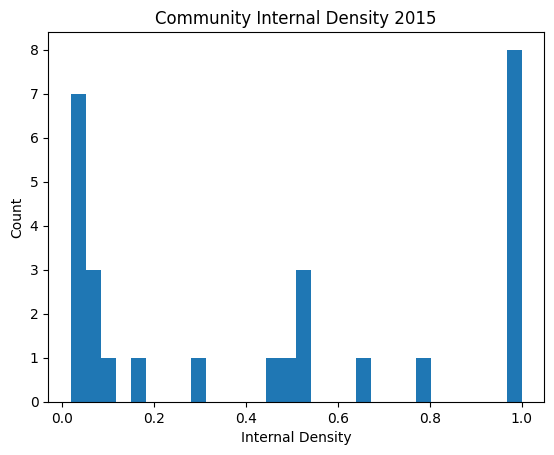

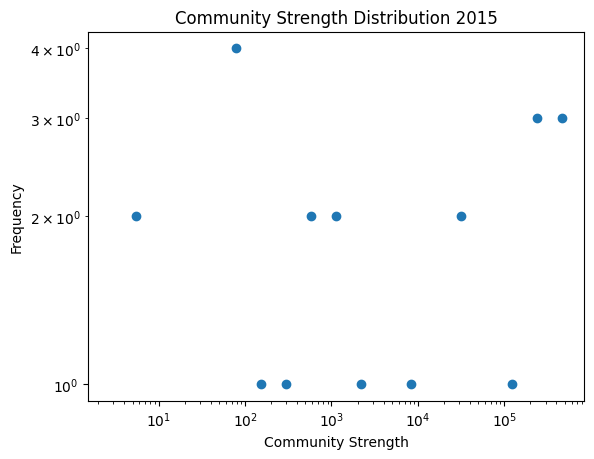

Top communities (by size): [np.int64(1990), np.int64(970), np.int64(765), np.int64(715), np.int64(689)]

===== COMMUNITY ANALYSIS: 2025 =====
Modularity: 0.7196278461632764
Number of communities: 34


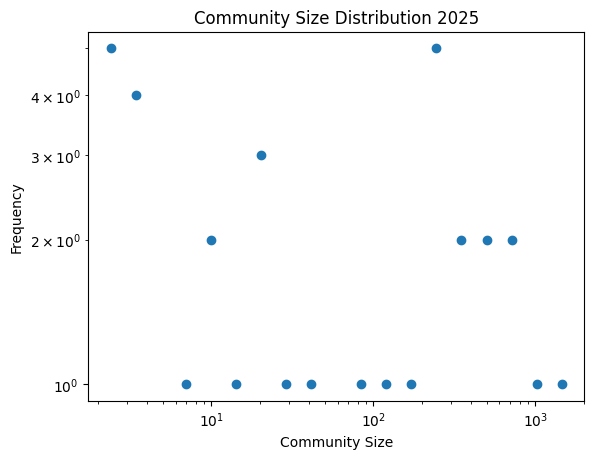

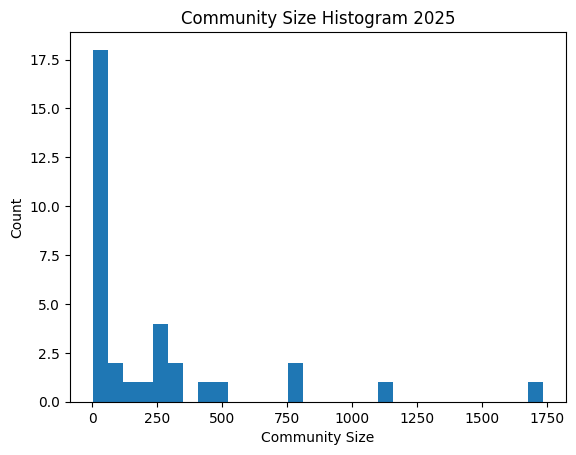

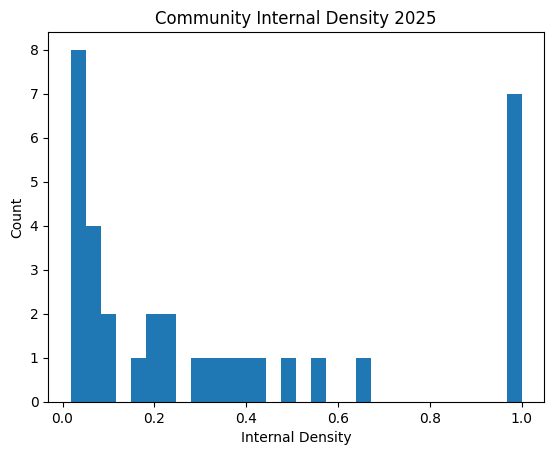

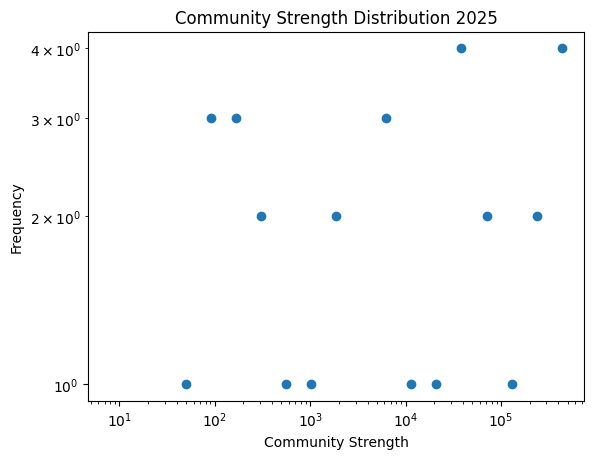

Top communities (by size): [np.int64(1735), np.int64(1146), np.int64(760), np.int64(753), np.int64(468)]


In [8]:
df_2015 = pd.read_csv("/kaggle/input/datasets/debjitbanerji/shipping-data/events_2015_full.csv")
df_2025 = pd.read_csv("/kaggle/input/datasets/debjitbanerji/shipping-data/events_2025_full.csv")

# Convert timestamps
df_2015["entry_time"] = pd.to_datetime(df_2015["entry_time"])
df_2015["exit_time"] = pd.to_datetime(df_2015["exit_time"])
df_2025["entry_time"] = pd.to_datetime(df_2025["entry_time"])
df_2025["exit_time"] = pd.to_datetime(df_2025["exit_time"])

# Sort globally (important)
df_2015 = df_2015.sort_values(["ship_id", "entry_time"])
df_2025 = df_2025.sort_values(["ship_id", "entry_time"])

MIN_TIME_GAP_HRS = 1

df_2015["gap"] = df_2015.groupby("ship_id")["entry_time"].diff().dt.total_seconds() / 3600
df_2025["gap"] = df_2025.groupby("ship_id")["entry_time"].diff().dt.total_seconds() / 3600

df_2015 = df_2015[(df_2015["gap"].isna()) | (df_2015["gap"] < 1000)]  # tune threshold
df_2025 = df_2025[(df_2025["gap"].isna()) | (df_2025["gap"] < 1000)]  # tune threshold


# =========================
# COMMUNITY ANALYSIS
# =========================

ship_seq_2015 = build_ship_sequences(df_2015)
Gd_2015 = build_directed_weighted_graph(ship_seq_2015)
Gu_2015 = build_undirected_weighted_graph(Gd_2015)

ship_seq_2025 = build_ship_sequences(df_2025)
Gd_2025 = build_directed_weighted_graph(ship_seq_2025)
Gu_2025 = build_undirected_weighted_graph(Gd_2025)


comm_2015 = community_report(Gd_2015, Gu_2015, "2015")
comm_2025 = community_report(Gd_2025, Gu_2025, "2025")